# DAY 6 — Customer Segmentation

## Main Project

## Customer Segmentation using K-Means

### 8. Step 1 - Import Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 9. Step 2 - Load the Dataset

In [45]:
df = pd.read_csv("Mall_Customers.csv")

print(df.head())
print(df.info())
print(df.shape)
print(df.columns)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
(200, 5)
Index(['CustomerID', 'Gender', 'Age', 'Ann

### 10. Step 3 - Explore data

In [46]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### 11. Step 4 - Select Features

In [49]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [50]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### 12. Step 5 — Scale the Features

In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### 13. Step 6 - Find a Suitable K

We don't automatically know how many customer groups exist.

For example:

K = 2

K = 3

K = 4

K = 5

K = 6

...

We need evidence for our choice.

Two important techniques from this week are:

1. Elbow Method
2. Silhouette Score

### 14. Elbow Method

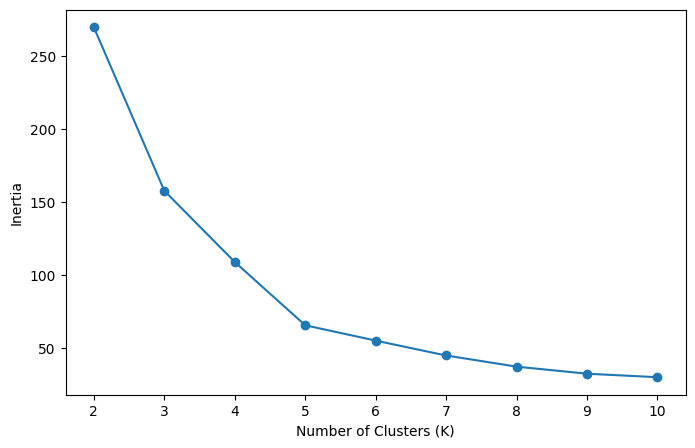

In [52]:
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

#### You look fot the point where the improvement begins to slow down significantly. The point is called the elbow.

### 15. Silhouette Score

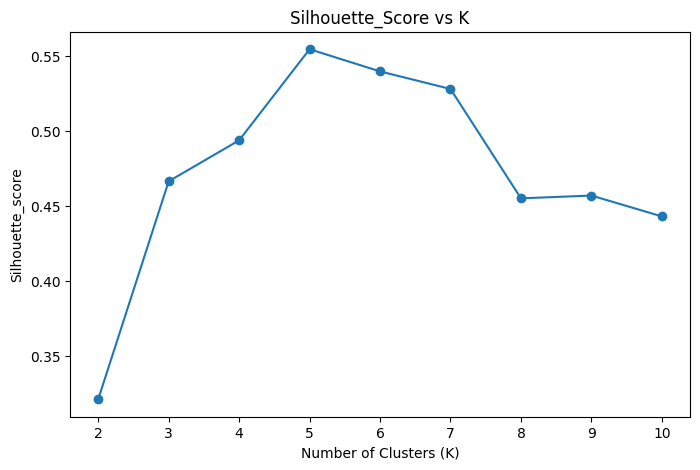

In [53]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
    )
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette_score")
plt.title("Silhouette_Score vs K")
plt.show()

A higher silhouette score generally indicates better-separated and more cohesive clusters.

#### Important

Do not blindly say:

"The highest silhouette score is always the correct K."

Model selection also requires:

cluster interpretability

business usefulness

cluster size

stability

domain knowledge

### 16. Step 7 - Train the K-Means Model

In [54]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

### 17. Step 8 - Add Cluster Labels

In [55]:
df["Cluster"] = clusters

In [56]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### 19. Step 9 — Analyze the Clusters

This is where machine learning becomes business intelligence.

Calculate average values:

In [73]:
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


Also check the number of customers:

In [82]:
cluster_sizes = df["Cluster"].value_counts().sort_index()
cluster_sizes

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

### 21. Visualization

Because we selected two features, visualization is straightforward.

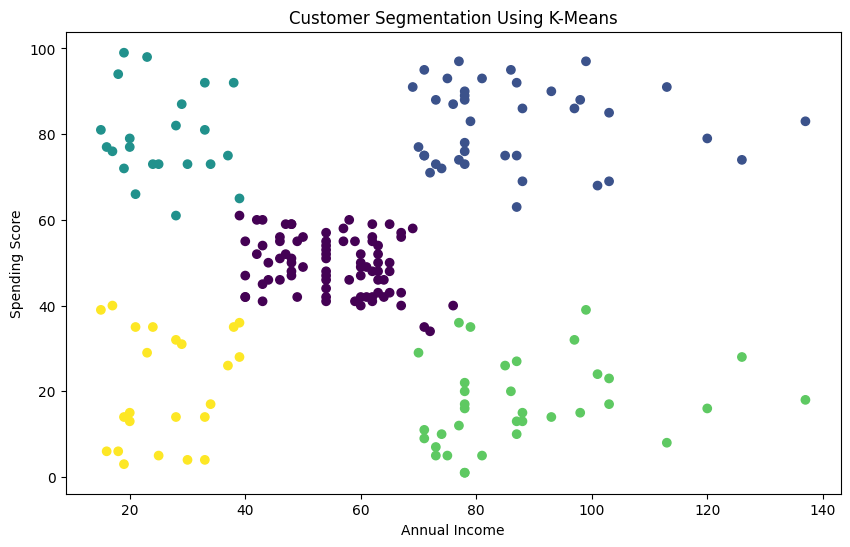

In [91]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation Using K-Means")

plt.show()

This allows you to visually inspect the discovered customer groups.

### 22. Visualizing the Centroids

We can also plot the cluster centers.

Remember:

The K-Means model learned the centroids in scaled space.

Therefore, transform them back to the original feature scale:

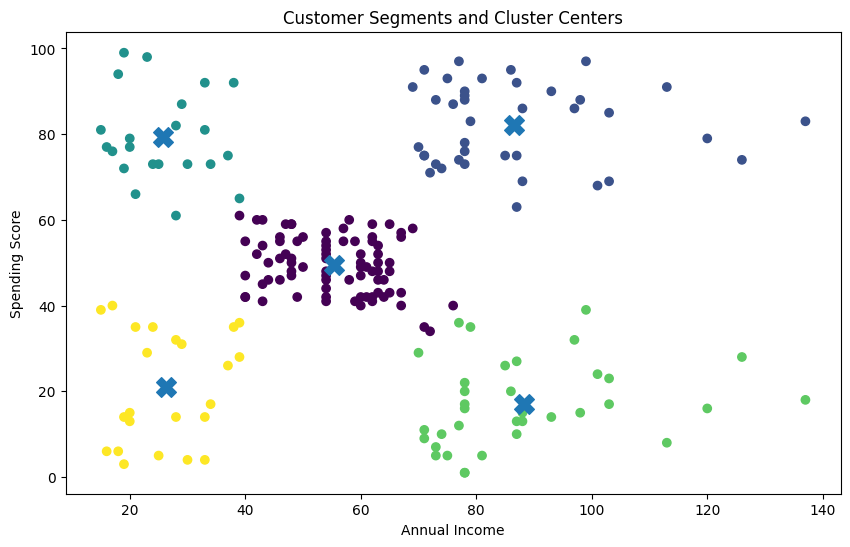

In [93]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments and Cluster Centers")

plt.show()

The X markers represent the approximate center of each cluster.